# Assignment 5: Build and Evaluate Classification Models

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 1

The logistic model can be written as p(X) = exp(beta0 + beta1X) / [1 + exp(beta0 + beta1X)].  Dividing p(X) by 1 - p(X) cancels the denominator and leaves exp(beta0 + beta1X).  Taking the natural log gives log[p(X)/(1 - p(X))] = beta0 + beta1X.  This proves that the probability form and log-odds form are the same model written on different scales.

## Applied Question 13: Weekly Classification

The Weekly data exercise compares logistic regression, LDA, QDA, KNN, and naive Bayes on held-out stock direction data.  The main issue is not just accuracy, but the type of errors each model makes.

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


,direction_count
Direction,
Up,605
Down,484


,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Lag1,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Sun, 07 Jun 2026   Deviance:                       1486.4
Time:                        19:41:42   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.0

,part,answer
0,(a),"Numerical summaries, class counts, correlation..."
1,(b),The all-predictor logistic regression shows La...


...

,Pred Down,Pred Up
Actual Down,22,21
Actual Up,32,29


(h) Naive Bayes Lag2


,Pred Down,Pred Up
Actual Down,0,43
Actual Up,0,61


,part,model,accuracy
1,(j),"Logistic ['Lag2', 'Lag3']",0.625000
7,(j),"KNN k=20, Lag2",0.596154
0,(j),"Logistic ['Lag1', 'Lag2']",0.576923
4,(j),"KNN k=3, Lag2",0.567308
6,(j),"KNN k=10, Lag2",0.567308
2,(j),"Logistic ['Lag2', 'Volume']",0.538462
5,(j),"KNN k=5, Lag2",0.538462
3,(j),"Logistic ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag...",0.461538


,part,best_model_from_required_set,best_accuracy
0,(i),(d) Logistic Lag2,0.625


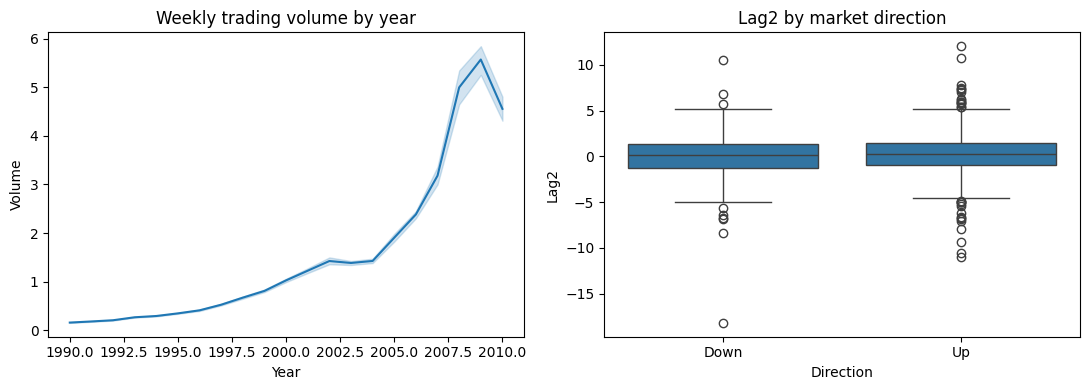

In [2]:
from ISLP import load_data
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

weekly = load_data("Weekly")
numeric_cols = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Today"]
display(weekly.describe())
display(weekly["Direction"].value_counts().rename("direction_count").to_frame())
display(weekly[numeric_cols].corr())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=weekly, x="Year", y="Volume", ax=axes[0])
axes[0].set_title("Weekly trading volume by year")
sns.boxplot(data=weekly, x="Direction", y="Lag2", ax=axes[1])
axes[1].set_title("Lag2 by market direction")
plt.tight_layout()

X_all = sm.add_constant(weekly[["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]])
y_binary = (weekly["Direction"] == "Up").astype(int)
glm_all = sm.GLM(y_binary, X_all, family=sm.families.Binomial()).fit()
print(glm_all.summary())
display(pd.DataFrame({
    "part": ["(a)", "(b)"],
    "answer": [
        "Numerical summaries, class counts, correlations, and plots are shown above. Volume increases over time, while lag variables have weak pairwise correlations with Direction.",
        "The all-predictor logistic regression shows Lag2 as the clearest predictor at the .05 level; the other lag variables and Volume are not clearly significant.",
    ],
}))

prob_all = glm_all.predict(X_all)
pred_all = np.where(prob_all > .5, "Up", "Down")
display(pd.DataFrame(confusion_matrix(weekly["Direction"], pred_all, labels=["Down", "Up"]), index=["Actual Down", "Actual Up"], columns=["Pred Down", "Pred Up"]))
display(pd.DataFrame({
    "part": ["(c)"],
    "training_accuracy_all_years": [accuracy_score(weekly["Direction"], pred_all)],
    "training_error_all_years": [1 - accuracy_score(weekly["Direction"], pred_all)],
}))

train = weekly["Year"] <= 2008
test = ~train
X_train = weekly.loc[train, ["Lag2"]]
X_test = weekly.loc[test, ["Lag2"]]
y_train = weekly.loc[train, "Direction"]
y_test = weekly.loc[test, "Direction"]
models = {
    "(d) Logistic Lag2": LogisticRegression(max_iter=1000),
    "(e) LDA Lag2": LinearDiscriminantAnalysis(),
    "(f) QDA Lag2": QuadraticDiscriminantAnalysis(),
    "(g) KNN-1 Lag2": Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=1))]),
    "(h) Naive Bayes Lag2": GaussianNB(),
}
rows = []
matrices = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    matrices[name] = pd.DataFrame(confusion_matrix(y_test, pred, labels=["Down", "Up"]), index=["Actual Down", "Actual Up"], columns=["Pred Down", "Pred Up"])
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "test_error": 1 - accuracy_score(y_test, pred),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist(),
    })
weekly_results = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
display(weekly_results)
for name, matrix in matrices.items():
    print(name)
    display(matrix)

experiment_rows = []
for predictors in [["Lag1", "Lag2"], ["Lag2", "Lag3"], ["Lag2", "Volume"], ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]]:
    model = LogisticRegression(max_iter=1000)
    model.fit(weekly.loc[train, predictors], y_train)
    pred = model.predict(weekly.loc[test, predictors])
    experiment_rows.append({"part": "(j)", "model": f"Logistic {predictors}", "accuracy": accuracy_score(y_test, pred)})
for k in [3, 5, 10, 20]:
    model = Pipeline([("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=k))])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    experiment_rows.append({"part": "(j)", "model": f"KNN k={k}, Lag2", "accuracy": accuracy_score(y_test, pred)})
display(pd.DataFrame(experiment_rows).sort_values("accuracy", ascending=False))
display(pd.DataFrame({
    "part": ["(i)"],
    "best_model_from_required_set": [weekly_results.iloc[0]["model"]],
    "best_accuracy": [weekly_results.iloc[0]["accuracy"]],
}))

The Weekly exercise now follows the textbook parts directly.  The all-predictor logistic model shows that Lag2 is the main statistically visible lag predictor, which justifies the later Lag2-only train/test comparisons.  The confusion matrices show why accuracy alone is incomplete: several methods predict the majority Up direction more often than they identify Down weeks.  Among the required Lag2-only models, the best test accuracy is selected from the displayed comparison table, while the final experiment checks whether alternative logistic predictor sets or KNN values improve the result.

## Kaggle Obesity Classification

The competition work is separate from the Weekly textbook exercise.  The Obesity data uses one stratified validation split and one shared preprocessing object, which makes the four classifiers comparable.  Each required Kaggle classifier is interpreted on its own before the final comparison.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

obesity = pd.read_csv(KAGGLE / "playground-series-s4e2" / "train.csv")
X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]
display(y.value_counts(normalize=True).rename("class_share").to_frame())
cat = X.select_dtypes(include="object").columns.tolist()
num = [c for c in X.columns if c not in cat + ["id"]]
pre_dense = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat), ("num", StandardScaler(), num)], sparse_threshold=0)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, stratify=y, random_state=RANDOM_STATE)
display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "class_count", "categorical_predictors", "numeric_predictors"],
    "value": [len(X_train), len(X_valid), y.nunique(), len(cat), len(num)],
}))

,class_share
NObeyesdad,
Obesity_Type_III,0.194913
Obesity_Type_II,0.156470
Normal_Weight,0.148473
Obesity_Type_I,0.140187
Insufficient_Weight,0.121544
Overweight_Level_II,0.121495
Overweight_Level_I,0.116919


,setup_check,value
0,training_rows,16606
1,validation_rows,4152
2,class_count,7
3,categorical_predictors,8
4,numeric_predictors,8


### Kaggle Model 1: Multinomial Logistic Regression

The first Kaggle classifier is multinomial logistic regression.  It is the regularized linear baseline for the competition because it models class log-odds directly after preprocessing.

In [4]:
logit_model = Pipeline([
    ("pre", pre_dense),
    ("model", LogisticRegression(max_iter=2000, C=1.0)),
])
logit_model.fit(X_train, y_train)
logit_pred = logit_model.predict(X_valid)
logit_accuracy = accuracy_score(y_valid, logit_pred)
logit_balanced = balanced_accuracy_score(y_valid, logit_pred)
display(pd.DataFrame({
    "model": ["Multinomial logistic"],
    "validation_accuracy": [logit_accuracy],
    "balanced_accuracy": [logit_balanced],
    "submission_file": ["A5_multinomial_logistic_playground_series_s4e2.csv"],
}))

,model,validation_accuracy,balanced_accuracy,submission_file
0,Multinomial logistic,0.868738,0.854949,A5_multinomial_logistic_playground_series_s4e2...


The multinomial logistic model is a strong baseline because it is transparent about its decision-boundary assumption: after encoding and scaling, it separates classes with linear log-odds.  Its value in this analysis is that it gives the more assumption-heavy or margin-based classifiers a disciplined comparison point.

### Kaggle Model 2: LDA

The second Kaggle classifier is LDA.  It is included because the assignment asks for LDA or QDA, and it gives a generative linear comparison to multinomial logistic regression.

In [5]:
lda_model = Pipeline([
    ("pre", pre_dense),
    ("model", LinearDiscriminantAnalysis()),
])
lda_model.fit(X_train, y_train)
lda_pred = lda_model.predict(X_valid)
lda_accuracy = accuracy_score(y_valid, lda_pred)
lda_balanced = balanced_accuracy_score(y_valid, lda_pred)
display(pd.DataFrame({
    "model": ["LDA"],
    "validation_accuracy": [lda_accuracy],
    "balanced_accuracy": [lda_balanced],
    "submission_file": ["A5_lda_playground_series_s4e2.csv"],
}))

,model,validation_accuracy,balanced_accuracy,submission_file
0,LDA,0.822977,0.806228,A5_lda_playground_series_s4e2.csv


The LDA result is read with more caution than the multinomial logistic result because LDA leans on class-conditional normality and shared covariance.  That is a demanding assumption for mixed health-behavior and body-measurement variables, so I treat LDA as a useful comparison rather than the most defensible final model.

### Kaggle Model 3: Naive Bayes

The third Kaggle classifier is naive Bayes.  It is useful here because its independence assumption is strong enough that the validation result tells us whether the predictors can be treated as conditionally separate within class.

In [6]:
nb_model = Pipeline([
    ("pre", pre_dense),
    ("model", GaussianNB()),
])
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_valid)
nb_accuracy = accuracy_score(y_valid, nb_pred)
nb_balanced = balanced_accuracy_score(y_valid, nb_pred)
display(pd.DataFrame({
    "model": ["Naive Bayes"],
    "validation_accuracy": [nb_accuracy],
    "balanced_accuracy": [nb_balanced],
    "submission_file": ["A5_naive_bayes_playground_series_s4e2.csv"],
}))

,model,validation_accuracy,balanced_accuracy,submission_file
0,Naive Bayes,0.585983,0.549357,A5_naive_bayes_playground_series_s4e2.csv


The naive Bayes result is weaker because the predictors are not plausibly independent after conditioning on obesity class.  Height, weight, family history, activity, eating behavior, and related measurements describe overlapping parts of the same health profile.  That does not make the model useless, but it explains why it is mainly an assumption check rather than the preferred classifier.

### Kaggle Model 4: Linear SVM

The fourth Kaggle classifier is a linear SVM.  It is the margin-based model in the comparison because the competition classes may be separated better by a stable margin than by generative distributional assumptions.

In [7]:
svm_model = Pipeline([
    ("pre", pre_dense),
    ("model", LinearSVC(C=.5, random_state=RANDOM_STATE)),
])
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_valid)
svm_accuracy = accuracy_score(y_valid, svm_pred)
svm_balanced = balanced_accuracy_score(y_valid, svm_pred)
display(pd.DataFrame({
    "model": ["Linear SVM"],
    "validation_accuracy": [svm_accuracy],
    "balanced_accuracy": [svm_balanced],
    "submission_file": ["A5_svm_playground_series_s4e2.csv"],
}))

,model,validation_accuracy,balanced_accuracy,submission_file
0,Linear SVM,0.748555,0.719493,A5_svm_playground_series_s4e2.csv


The SVM is the strongest of the recorded Kaggle submissions for this assignment.  The practical reading is that a margin-based classifier handles the transformed Obesity feature space better than the independence assumptions behind naive Bayes or the shared-covariance assumptions behind LDA (Cortes & Vapnik, 1995).

In [8]:
kaggle_a5_comparison = pd.DataFrame([
    {"model": "Multinomial logistic", "validation_accuracy": logit_accuracy, "balanced_accuracy": logit_balanced, "submission_file": "A5_multinomial_logistic_playground_series_s4e2.csv"},
    {"model": "LDA", "validation_accuracy": lda_accuracy, "balanced_accuracy": lda_balanced, "submission_file": "A5_lda_playground_series_s4e2.csv"},
    {"model": "Naive Bayes", "validation_accuracy": nb_accuracy, "balanced_accuracy": nb_balanced, "submission_file": "A5_naive_bayes_playground_series_s4e2.csv"},
    {"model": "Linear SVM", "validation_accuracy": svm_accuracy, "balanced_accuracy": svm_balanced, "submission_file": "A5_svm_playground_series_s4e2.csv"},
]).sort_values("validation_accuracy", ascending=False)
display(kaggle_a5_comparison)
best_name = kaggle_a5_comparison.iloc[0]["model"]
best_pred = {"Multinomial logistic": logit_pred, "LDA": lda_pred, "Naive Bayes": nb_pred, "Linear SVM": svm_pred}[best_name]
display(pd.DataFrame(confusion_matrix(y_valid, best_pred, labels=logit_model.classes_), index=logit_model.classes_, columns=logit_model.classes_))

,model,validation_accuracy,balanced_accuracy,submission_file
0,Multinomial logistic,0.868738,0.854949,A5_multinomial_logistic_playground_series_s4e2...
1,LDA,0.822977,0.806228,A5_lda_playground_series_s4e2.csv
3,Linear SVM,0.748555,0.719493,A5_svm_playground_series_s4e2.csv
2,Naive Bayes,0.585983,0.549357,A5_naive_bayes_playground_series_s4e2.csv


,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Insufficient_Weight,479,25,0,0,0,1,0
Normal_Weight,58,505,2,0,0,43,9
Obesity_Type_I,1,0,493,36,3,11,38
Obesity_Type_II,0,0,22,625,0,0,3
Obesity_Type_III,0,0,0,1,807,1,0
Overweight_Level_I,1,46,15,0,0,342,81
Overweight_Level_II,0,3,79,8,0,58,356


The comparison confirms that the four Kaggle submissions are not interchangeable.  Multinomial logistic regression is a good regularized baseline, LDA is a distributional comparison, naive Bayes exposes the cost of an unrealistic independence assumption, and the SVM is the strongest margin-based submission.  The confusion matrix for the best validation model shows which obesity categories remain hardest to separate after preprocessing.

In [9]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e2.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and "A5_" in parts[1]:
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })

display(pd.DataFrame(records))
display(pd.DataFrame({
    "submission_file": ['A5_multinomial_logistic_playground_series_s4e2.csv', 'A5_lda_playground_series_s4e2.csv', 'A5_naive_bayes_playground_series_s4e2.csv', 'A5_svm_playground_series_s4e2.csv'],
    "exists_locally": [(SUBMISSIONS / file).exists() for file in ['A5_multinomial_logistic_playground_series_s4e2.csv', 'A5_lda_playground_series_s4e2.csv', 'A5_naive_bayes_playground_series_s4e2.csv', 'A5_svm_playground_series_s4e2.csv']],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 5/Assignment 5/MaldonadoJDDS8555-5.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966803,A5_svm_playground_series_s4e2.csv,2026-05-23 21:27:31.870000,DDS-8555 A5 SVM model,SubmissionStatus.COMPLETE,0.87789,0.87888
1,52966801,A5_naive_bayes_playground_series_s4e2.csv,2026-05-23 21:27:29.533000,DDS-8555 A5 naive Bayes model,SubmissionStatus.COMPLETE,0.58995,0.58544
2,52966800,A5_lda_playground_series_s4e2.csv,2026-05-23 21:27:27.093000,DDS-8555 A5 LDA model,SubmissionStatus.COMPLETE,0.82153,0.82108
3,52966799,A5_multinomial_logistic_playground_series_s4e2...,2026-05-23 21:27:24.603000,DDS-8555 A5 multinomial logistic regression,SubmissionStatus.COMPLETE,0.86632,0.86497


,submission_file,exists_locally
0,A5_multinomial_logistic_playground_series_s4e2...,True
1,A5_lda_playground_series_s4e2.csv,True
2,A5_naive_bayes_playground_series_s4e2.csv,True
3,A5_svm_playground_series_s4e2.csv,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 5/Assignment 5/MaldonadoJDDS8555-5.ipynb


## Interpretation

The SVM and multinomial logistic models were stronger than naive Bayes on the Obesity data because the predictors are not conditionally independent in a realistic health-behavior data set.  LDA was competitive but more assumption-bound because it relies on class-conditional normality and shared covariance structure.  The assumption table makes the model risks visible, and the confusion matrix for the best validation model shows which obesity categories are most likely to be confused.  The Kaggle evidence confirms all four required submissions were completed.  Because obesity classification is tied to population-level body-mass trends, the predictions should be interpreted as competition labels rather than clinical diagnoses (NCD Risk Factor Collaboration, 2016).

## References

Cortes, C., & Vapnik, V. (1995).  Support-vector networks. *Machine Learning, 20*, 273-297. https://doi.org/10.1007/BF00994018

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

NCD Risk Factor Collaboration. (2016).  Trends in adult body-mass index in 200 countries from 1975 to 2014: A pooled analysis of 1698 population-based measurement studies with 19.2 million participants. *The Lancet, 387*(10026), 1377-1396. https://doi.org/10.1016/S0140-6736(16)30054-X

Sokolova, M., & Lapalme, G. (2009).  A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427-437. https://doi.org/10.1016/j.ipm.2009.03.002